In [20]:
import pandas as pd
import numpy as np

In [21]:
df = pd.read_csv("ev_charging_dataset.csv")

In [22]:
df.head()

,Date_Time,Vehicle_ID,Battery_Capacity_kWh,State_of_Charge_%,Energy_Consumption_Rate_kWh/km,Current_Latitude,Current_Longitude,Destination_Latitude,Destination_Longitude,Distance_to_Destination_km,...,Session_Start_Hour,Fleet_Size,Fleet_Schedule,Temperature_C,Wind_Speed_m/s,Precipitation_mm,Weekday,Charging_Preferences,Weather_Conditions,Charging_Load_kW
0,2017-01-01 00:00:00,106,66.746483,50.216524,0.153521,32.777266,-96.788301,32.784014,-96.795776,30.531144,...,6,10,0,13.954368,0.144765,0.712211,1,0,Cloudy,30.839677
1,2017-01-01 01:00:00,106,82.731496,59.358609,0.119101,32.779136,-96.786137,32.778406,-96.798310,1.004305,...,6,10,0,38.926466,0.461061,2.746260,3,0,Cloudy,47.354691
2,2017-01-01 02:00:00,106,82.107913,14.460831,0.100000,32.769346,-96.802470,32.770487,-96.795953,5.289772,...,6,50,0,22.164516,0.708376,2.502156,4,1,Clear,44.459198
3,2017-01-01 03:00:00,106,95.526752,23.003923,0.286505,32.766093,-96.790229,32.765745,-96.818855,7.267380,...,6,200,0,16.000845,1.591273,1.796916,3,0,Clear,52.468801
4,2017-01-01 04:00:00,106,61.247597,9.064810,0.100000,32.796174,-96.782421,32.765489,-96.791241,32.449058,...,6,10,1,23.170368,1.753500,1.547112,2,0,Clear,53.473756


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64945 entries, 0 to 64944
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date_Time                       64945 non-null  object 
 1   Vehicle_ID                      64945 non-null  int64  
 2   Battery_Capacity_kWh            64945 non-null  float64
 3   State_of_Charge_%               64945 non-null  float64
 4   Energy_Consumption_Rate_kWh/km  64945 non-null  float64
 5   Current_Latitude                64945 non-null  float64
 6   Current_Longitude               64945 non-null  float64
 7   Destination_Latitude            64945 non-null  float64
 8   Destination_Longitude           64945 non-null  float64
 9   Distance_to_Destination_km      64945 non-null  float64
 10  Traffic_Data                    64945 non-null  int64  
 11  Road_Conditions                 64945 non-null  object 
 12  Charging_Station_ID             

In [24]:
df.shape

(64945, 28)

In [25]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("%", "")
df.columns = df.columns.str.replace("/", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")

print(df.columns)

Index(['Date_Time', 'Vehicle_ID', 'Battery_Capacity_kWh', 'State_of_Charge_',
       'Energy_Consumption_Rate_kWh_km', 'Current_Latitude',
       'Current_Longitude', 'Destination_Latitude', 'Destination_Longitude',
       'Distance_to_Destination_km', 'Traffic_Data', 'Road_Conditions',
       'Charging_Station_ID', 'Charging_Rate_kW', 'Queue_Time_mins',
       'Station_Capacity_EV', 'Time_Spent_Charging_mins', 'Energy_Drawn_kWh',
       'Session_Start_Hour', 'Fleet_Size', 'Fleet_Schedule', 'Temperature_C',
       'Wind_Speed_m_s', 'Precipitation_mm', 'Weekday', 'Charging_Preferences',
       'Weather_Conditions', 'Charging_Load_kW'],
      dtype='object')


In [26]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'])

df['Hour'] = df['Date_Time'].dt.hour
df['Day'] = df['Date_Time'].dt.day
df['Month'] = df['Date_Time'].dt.month

df.head()

,Date_Time,Vehicle_ID,Battery_Capacity_kWh,State_of_Charge_,Energy_Consumption_Rate_kWh_km,Current_Latitude,Current_Longitude,Destination_Latitude,Destination_Longitude,Distance_to_Destination_km,...,Temperature_C,Wind_Speed_m_s,Precipitation_mm,Weekday,Charging_Preferences,Weather_Conditions,Charging_Load_kW,Hour,Day,Month
0,2017-01-01 00:00:00,106,66.746483,50.216524,0.153521,32.777266,-96.788301,32.784014,-96.795776,30.531144,...,13.954368,0.144765,0.712211,1,0,Cloudy,30.839677,0,1,1
1,2017-01-01 01:00:00,106,82.731496,59.358609,0.119101,32.779136,-96.786137,32.778406,-96.798310,1.004305,...,38.926466,0.461061,2.746260,3,0,Cloudy,47.354691,1,1,1
2,2017-01-01 02:00:00,106,82.107913,14.460831,0.100000,32.769346,-96.802470,32.770487,-96.795953,5.289772,...,22.164516,0.708376,2.502156,4,1,Clear,44.459198,2,1,1
3,2017-01-01 03:00:00,106,95.526752,23.003923,0.286505,32.766093,-96.790229,32.765745,-96.818855,7.267380,...,16.000845,1.591273,1.796916,3,0,Clear,52.468801,3,1,1
4,2017-01-01 04:00:00,106,61.247597,9.064810,0.100000,32.796174,-96.782421,32.765489,-96.791241,32.449058,...,23.170368,1.753500,1.547112,2,0,Clear,53.473756,4,1,1


In [27]:
df.dtypes

,0
Date_Time,datetime64[ns]
Vehicle_ID,int64
Battery_Capacity_kWh,float64
State_of_Charge_,float64
Energy_Consumption_Rate_kWh_km,float64
Current_Latitude,float64
Current_Longitude,float64
Destination_Latitude,float64
Destination_Longitude,float64
Distance_to_Destination_km,float64


In [28]:
df['Vehicle_ID'] = df['Vehicle_ID'].astype(int)

In [30]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
df = df.drop_duplicates()
print("After removing duplicates:", df.duplicated().sum())

Number of duplicate rows: 0
After removing duplicates: 0


In [31]:
df.isnull().sum()

,0
Date_Time,0
Vehicle_ID,0
Battery_Capacity_kWh,0
State_of_Charge_,0
Energy_Consumption_Rate_kWh_km,0
Current_Latitude,0
Current_Longitude,0
Destination_Latitude,0
Destination_Longitude,0
Distance_to_Destination_km,0


In [37]:
df.describe()

,Date_Time,Vehicle_ID,Battery_Capacity_kWh,State_of_Charge_,Energy_Consumption_Rate_kWh_km,Current_Latitude,Current_Longitude,Destination_Latitude,Destination_Longitude,Distance_to_Destination_km,...,Fleet_Schedule,Temperature_C,Wind_Speed_m_s,Precipitation_mm,Weekday,Charging_Preferences,Charging_Load_kW,Hour,Day,Month
count,64945,64945.0,64945.000000,64945.000000,64945.000000,64945.000000,64945.000000,64945.000000,64945.000000,64945.000000,...,64945.000000,64945.000000,64945.000000,64945.000000,64945.000000,64945.000000,64945.000000,64945.000000,64945.000000,64945.000000
mean,2020-09-15 00:00:00,106.0,74.725734,28.480992,0.177172,32.776689,-96.797052,32.776679,-96.796963,14.953876,...,0.101286,24.654049,2.003830,2.003267,2.788837,0.198506,39.984615,11.499823,15.714189,6.327770
min,2017-01-01 00:00:00,106.0,30.000000,0.099346,0.100000,32.735193,-96.838816,32.736378,-96.838453,1.000000,...,0.000000,0.000000,0.000066,0.000009,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2018-11-08 12:00:00,106.0,64.935248,15.972907,0.100000,32.769904,-96.803747,32.769871,-96.803669,4.292956,...,0.000000,18.140208,0.570939,0.579747,1.000000,0.000000,33.247724,5.000000,8.000000,3.000000
50%,2020-09-15 00:00:00,106.0,74.969499,26.420173,0.139555,32.776654,-96.796997,32.776708,-96.796971,10.356013,...,0.000000,24.921663,1.382761,1.394821,3.000000,0.000000,40.027261,11.000000,16.000000,6.000000
75%,2022-07-23 12:00:00,106.0,85.134281,38.853891,0.278742,32.783478,-96.790258,32.783435,-96.790252,20.757014,...,0.000000,31.751901,2.786245,2.778826,4.000000,0.000000,46.702958,17.000000,23.000000,9.000000
max,2024-05-30 00:00:00,106.0,100.000000,89.662865,0.300000,32.818232,-96.756526,32.822891,-96.750380,100.000000,...,1.000000,40.000000,15.000000,21.262816,6.000000,1.000000,75.000000,23.000000,31.000000,12.000000
std,NaN,0.0,14.346408,15.939754,0.083414,0.010066,0.009974,0.010058,0.010005,14.791688,...,0.301709,9.409490,2.002506,1.995306,1.884965,0.398879,9.993323,6.922334,8.792154,3.464119


In [38]:
print("\nRoad Conditions:", df['Road_Conditions'].unique())
print("Weather Conditions:", df['Weather_Conditions'].unique())


Road Conditions: ['Good' 'Average' 'Poor']
Weather Conditions: ['Cloudy' 'Clear' 'Rain' 'Storm']


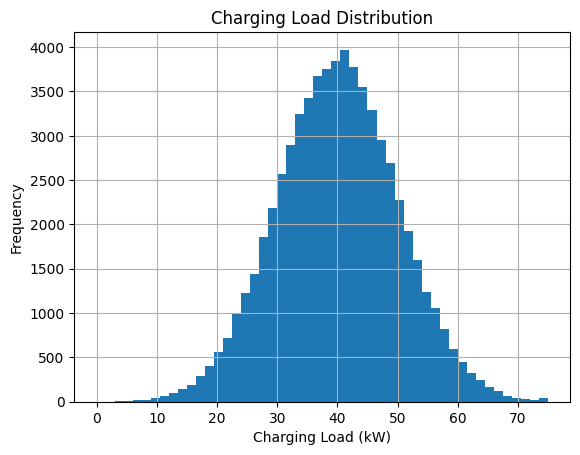

In [42]:
df['Charging_Load_kW'].hist(bins=50)
plt.title("Charging Load Distribution")
plt.xlabel("Charging Load (kW)")
plt.ylabel("Frequency")
plt.show()

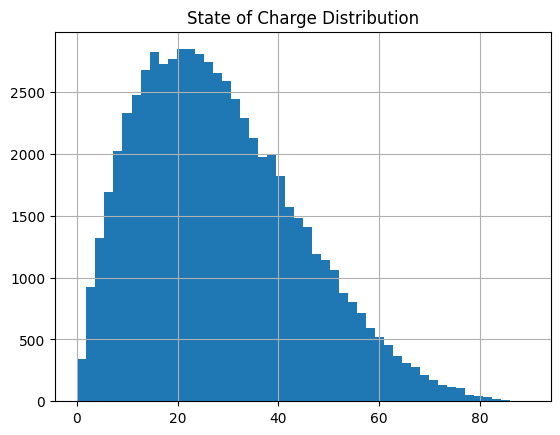

In [43]:
df['State_of_Charge_'].hist(bins=50)
plt.title("State of Charge Distribution")
plt.show()

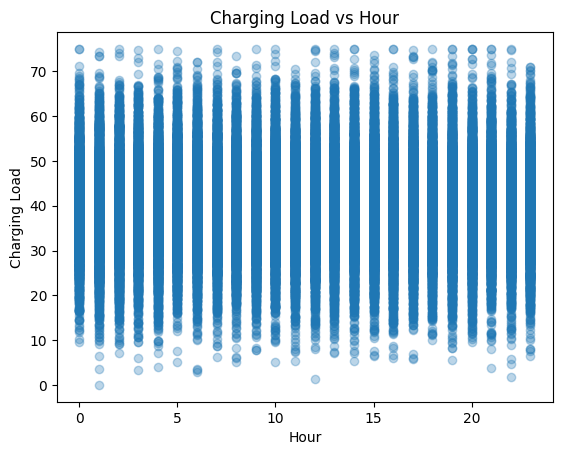

In [39]:
plt.scatter(df['Hour'], df['Charging_Load_kW'], alpha=0.3)
plt.title("Charging Load vs Hour")
plt.xlabel("Hour")
plt.ylabel("Charging Load")
plt.show()

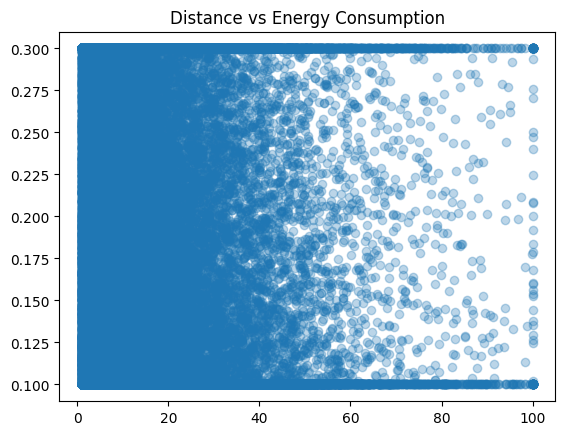

In [40]:
plt.scatter(df['Distance_to_Destination_km'], df['Energy_Consumption_Rate_kWh_km'], alpha=0.3)
plt.title("Distance vs Energy Consumption")
plt.show()

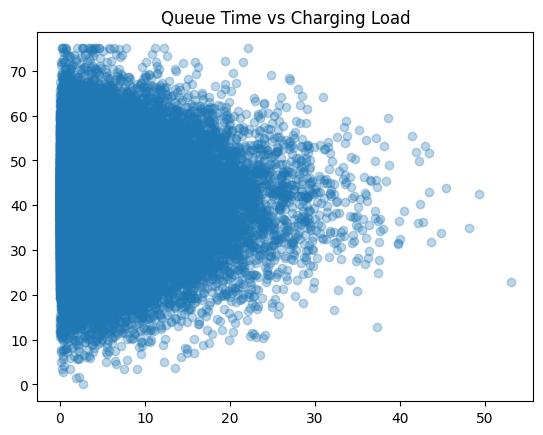

In [41]:
plt.scatter(df['Queue_Time_mins'], df['Charging_Load_kW'], alpha=0.3)
plt.title("Queue Time vs Charging Load")
plt.show()

In [44]:
df['Battery_Energy_kWh'] = (df['State_of_Charge_'] / 100) * df['Battery_Capacity_kWh']

df['Energy_Required_kWh'] = df['Distance_to_Destination_km'] * df['Energy_Consumption_Rate_kWh_km']

df['Energy_Deficit'] = df['Energy_Required_kWh'] - df['Battery_Energy_kWh']

In [45]:
df = pd.get_dummies(df, columns=['Road_Conditions', 'Weather_Conditions'], drop_first=True)

In [46]:
df = df.drop(columns=['Vehicle_ID', 'Charging_Station_ID', 'Date_Time'])

In [47]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [48]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)

In [49]:
state_features = [
    'State_of_Charge_',
    'Distance_to_Destination_km',
    'Traffic_Data',
    'Queue_Time_mins',
    'Battery_Energy_kWh',
    'Energy_Deficit',
    'Hour'
]

X_train = train_df[state_features]
X_test = test_df[state_features]

In [50]:
y_train = train_df['Charging_Load_kW']
y_test = test_df['Charging_Load_kW']

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.01844607005289576


In [52]:
train_df.to_csv("train_ev_data.csv", index=False)
test_df.to_csv("test_ev_data.csv", index=False)

In [53]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("train_ev_data.csv")

In [54]:
class EVEnvironment:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.current_step = 0
        self.max_steps = len(data)

    def reset(self):
        self.current_step = 0
        return self._get_state()

    def _get_state(self):
        row = self.data.iloc[self.current_step]
        return (
            round(row['State_of_Charge_'], 2),
            round(row['Distance_to_Destination_km'], 2),
            round(row['Traffic_Data'], 2),
            round(row['Queue_Time_mins'], 2),
            round(row['Energy_Deficit'], 2)
        )

    def step(self, action):
        row = self.data.iloc[self.current_step]

        reward = 0

        if action == 0:
            reward -= row['Distance_to_Destination_km'] * 0.5
            if row['Energy_Deficit'] > 0:
                reward -= 20

        elif action == 1:
            reward -= row['Queue_Time_mins'] * 0.2
            reward += 10

        elif action == 2:
            reward -= 5

        self.current_step += 1
        done = self.current_step >= self.max_steps

        next_state = self._get_state() if not done else None

        return next_state, reward, done

In [55]:
import random

class QLearningAgent:
    def __init__(self, actions):
        self.q_table = {}
        self.actions = actions
        self.alpha = 0.1
        self.gamma = 0.9
        self.epsilon = 0.2

    def get_q(self, state, action):
        return self.q_table.get((state, action), 0)

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)
        else:
            q_values = [self.get_q(state, a) for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state):
        current_q = self.get_q(state, action)

        if next_state is None:
            max_future_q = 0
        else:
            max_future_q = max([self.get_q(next_state, a) for a in self.actions])

        new_q = current_q + self.alpha * (reward + self.gamma * max_future_q - current_q)
        self.q_table[(state, action)] = new_q

In [56]:
env = EVEnvironment(train_df)
agent = QLearningAgent(actions=[0, 1, 2])

episodes = 50

for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    while True:
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)

        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward

        if done:
            break

    print(f"Episode {episode+1}: Total Reward = {total_reward}")

Episode 1: Total Reward = -977416.4028219876
Episode 2: Total Reward = 326351.62674172607
Episode 3: Total Reward = 401725.50468296243
Episode 4: Total Reward = 405421.564712795
Episode 5: Total Reward = 406125.105328294
Episode 6: Total Reward = 408731.21468524676
Episode 7: Total Reward = 406781.6112983576
Episode 8: Total Reward = 410978.13165713934
Episode 9: Total Reward = 406712.29862058884
Episode 10: Total Reward = 407808.2097586386
Episode 11: Total Reward = 409092.9336590901
Episode 12: Total Reward = 409003.07771706424
Episode 13: Total Reward = 410503.5887778107
Episode 14: Total Reward = 409887.47473552084
Episode 15: Total Reward = 410772.31647290493
Episode 16: Total Reward = 405998.2873095088
Episode 17: Total Reward = 407389.1551519825
Episode 18: Total Reward = 406558.69483014534
Episode 19: Total Reward = 406806.4375814356
Episode 20: Total Reward = 406060.64096244826
Episode 21: Total Reward = 410060.1069283115
Episode 22: Total Reward = 409200.1649811723
Episode 23

In [57]:
state = env.reset()
total_reward = 0

while True:
    action = agent.choose_action(state)
    next_state, reward, done = env.step(action)

    total_reward += reward
    state = next_state

    if done:
        break

print("Test Total Reward:", total_reward)

Test Total Reward: 406387.27405221766


In [58]:
# If not installed
# pip install torch

import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import pandas as pd
from collections import deque

In [59]:
train_df = pd.read_csv("train_ev_data.csv")

In [60]:
class EVEnvironment:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.max_steps = len(data)
        self.current_step = 0

    def reset(self):
        self.current_step = 0
        return self._get_state()

    def _get_state(self):
        row = self.data.iloc[self.current_step]
        return np.array([
            row['State_of_Charge_'],
            row['Distance_to_Destination_km'],
            row['Traffic_Data'],
            row['Queue_Time_mins'],
            row['Energy_Deficit'],
            row['Hour']
        ], dtype=np.float32)

    def step(self, action):
        row = self.data.iloc[self.current_step]

        reward = 0

        if action == 0:
            reward -= row['Distance_to_Destination_km']
            if row['Energy_Deficit'] > 0:
                reward -= 20

        elif action == 1:
            reward -= row['Queue_Time_mins']
            reward += 15

        elif action == 2:
            reward -= 5

        self.current_step += 1
        done = self.current_step >= self.max_steps

        next_state = self._get_state() if not done else np.zeros(6)

        return next_state, reward, done

In [61]:
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

In [62]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return zip(*batch)

    def __len__(self):
        return len(self.buffer)

In [63]:
env = EVEnvironment(train_df)

state_dim = 6
action_dim = 3

model = DQN(state_dim, action_dim)
target_model = DQN(state_dim, action_dim)

target_model.load_state_dict(model.state_dict())

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

buffer = ReplayBuffer()

In [64]:
episodes = 50
batch_size = 32
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

In [65]:
for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    while True:
        state_tensor = torch.FloatTensor(state)

        if random.random() < epsilon:
            action = random.randint(0, action_dim - 1)
        else:
            with torch.no_grad():
                q_values = model(state_tensor)
                action = torch.argmax(q_values).item()

        next_state, reward, done = env.step(action)

        buffer.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        if len(buffer) > batch_size:
            states, actions, rewards, next_states, dones = buffer.sample(batch_size)

            states = torch.FloatTensor(list(states))
            actions = torch.LongTensor(list(actions))
            rewards = torch.FloatTensor(list(rewards))
            next_states = torch.FloatTensor(list(next_states))
            dones = torch.FloatTensor(list(dones))

            q_values = model(states)
            next_q_values = target_model(next_states)

            q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze()
            max_next_q = next_q_values.max(1)[0]

            target = rewards + gamma * max_next_q * (1 - dones)

            loss = loss_fn(q_value, target.detach())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    target_model.load_state_dict(model.state_dict())

    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    print(f"Episode {episode+1}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

/tmp/ipykernel_1147/3538104390.py:25: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(list(states))


Episode 1, Reward: -196749.31592800794, Epsilon: 0.995
Episode 2, Reward: -197764.69826129626, Epsilon: 0.990
Episode 3, Reward: -191049.8038597777, Epsilon: 0.985
Episode 4, Reward: -184476.63866941334, Epsilon: 0.980
Episode 5, Reward: -175145.54432678552, Epsilon: 0.975
Episode 6, Reward: -170249.57874152632, Epsilon: 0.970
Episode 7, Reward: -172836.8895851677, Epsilon: 0.966
Episode 8, Reward: -162108.4707078297, Epsilon: 0.961
Episode 9, Reward: -155750.00592481837, Epsilon: 0.956
Episode 10, Reward: -154661.5699936681, Epsilon: 0.951
Episode 11, Reward: -149135.8099774249, Epsilon: 0.946
Episode 12, Reward: -146756.46605625597, Epsilon: 0.942
Episode 13, Reward: -138444.64439398548, Epsilon: 0.937
Episode 14, Reward: -128722.39545935196, Epsilon: 0.932
Episode 15, Reward: -127655.76805132639, Epsilon: 0.928
Episode 16, Reward: -120112.58993073601, Epsilon: 0.923
Episode 17, Reward: -115143.51536559568, Epsilon: 0.918
Episode 18, Reward: -113403.90069988374, Epsilon: 0.914
Episod

In [66]:
state = env.reset()
total_reward = 0

while True:
    state_tensor = torch.FloatTensor(state)

    with torch.no_grad():
        action = torch.argmax(model(state_tensor)).item()

    next_state, reward, done = env.step(action)

    total_reward += reward
    state = next_state

    if done:
        break

print("Test Total Reward:", total_reward)

Test Total Reward: 871219.590857536


In [67]:
torch.save(model.state_dict(), "dqn_ev_model.pth")

In [71]:
episode_rewards = []

In [72]:
episode_rewards.append(total_reward)

In [74]:
for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    while True:

        if done:
            break

    episode_rewards.append(total_reward)
    print(f"Episode {episode+1}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

Episode 1, Reward: 0, Epsilon: 0.778
Episode 2, Reward: 0, Epsilon: 0.778
Episode 3, Reward: 0, Epsilon: 0.778
Episode 4, Reward: 0, Epsilon: 0.778
Episode 5, Reward: 0, Epsilon: 0.778
Episode 6, Reward: 0, Epsilon: 0.778
Episode 7, Reward: 0, Epsilon: 0.778
Episode 8, Reward: 0, Epsilon: 0.778
Episode 9, Reward: 0, Epsilon: 0.778
Episode 10, Reward: 0, Epsilon: 0.778
Episode 11, Reward: 0, Epsilon: 0.778
Episode 12, Reward: 0, Epsilon: 0.778
Episode 13, Reward: 0, Epsilon: 0.778
Episode 14, Reward: 0, Epsilon: 0.778
Episode 15, Reward: 0, Epsilon: 0.778
Episode 16, Reward: 0, Epsilon: 0.778
Episode 17, Reward: 0, Epsilon: 0.778
Episode 18, Reward: 0, Epsilon: 0.778
Episode 19, Reward: 0, Epsilon: 0.778
Episode 20, Reward: 0, Epsilon: 0.778
Episode 21, Reward: 0, Epsilon: 0.778
Episode 22, Reward: 0, Epsilon: 0.778
Episode 23, Reward: 0, Epsilon: 0.778
Episode 24, Reward: 0, Epsilon: 0.778
Episode 25, Reward: 0, Epsilon: 0.778
Episode 26, Reward: 0, Epsilon: 0.778
Episode 27, Reward: 0

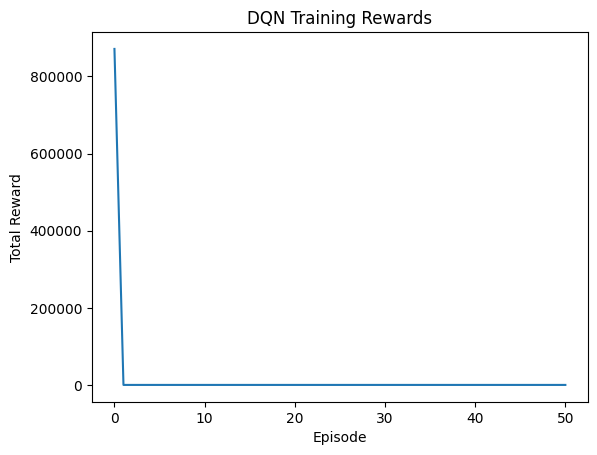

In [75]:
import matplotlib.pyplot as plt

plt.plot(episode_rewards)
plt.title("DQN Training Rewards")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

In [76]:
np.save("dqn_rewards.npy", episode_rewards)